In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("csv.csv")

In [5]:
import keras
import numpy as np
from keras import layers
from sklearn.model_selection import train_test_split

class AutoEncoder(keras.Model):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        self.encoder = keras.Sequential([
            layers.Input((100, 3)),
            layers.Flatten(),
            layers.Dense(64, activation='relu'),
            layers.Dense(16, activation='relu'),
            layers.Dense(8, activation='relu'),
        ])
        self.decoder = keras.Sequential([
            layers.Input((8, )),
            layers.Dense(16, activation='sigmoid'),
            layers.Dense(64, activation='sigmoid'),
            layers.Dense(300),
            layers.Reshape((100, 3))
        ])
    
    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = AutoEncoder()
autoencoder.compile(loss='mse', optimizer='adam')
x = np.zeros((50, 100, 3))
for id_0 in range(50):
    subset = df[df["id"] == id_0]
    x[id_0, :, 0] = subset["x"].values
    x[id_0, :, 1] = subset["y"].values
    x[id_0, :, 2] = subset["z"].values
    
history = autoencoder.fit(x, x, epochs=100, validation_split=0.3)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - loss: 1.7618 - val_loss: 1.7144
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.6837 - val_loss: 1.6543
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.6231 - val_loss: 1.6013
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.5602 - val_loss: 1.5539
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.4966 - val_loss: 1.5108
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.4564 - val_loss: 1.4727
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.4159 - val_loss: 1.4396
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.3753 - val_loss: 1.4096
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.3371 - val_loss: 1.3817
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.2999 - val_loss: 1.3567
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.2797 - val_loss: 1.3349
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.2471 - val_l

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


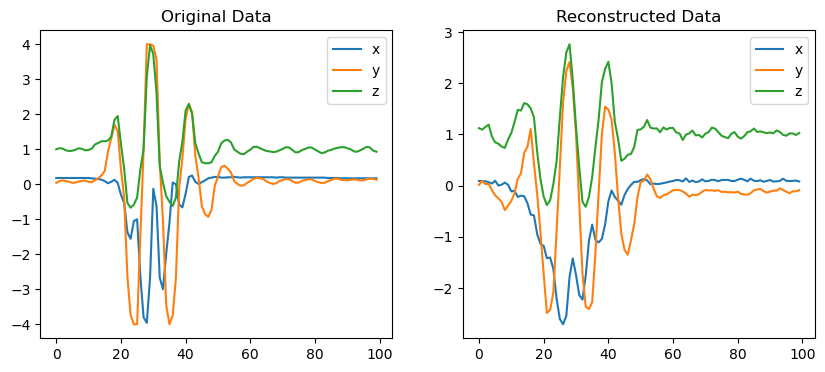

In [6]:
def plot_reconstruction(model, data, index=0):
    original = data[index]
    # Prédire toutes les données et sélectionner l'échantillon voulu
    reconstructed = model.predict(data)[index]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(original[:, 0], label="x")
    axes[0].plot(original[:, 1], label="y")
    axes[0].plot(original[:, 2], label="z")
    axes[0].set_title("Original Data")
    axes[0].legend()

    axes[1].plot(reconstructed[:, 0], label="x")
    axes[1].plot(reconstructed[:, 1], label="y")
    axes[1].plot(reconstructed[:, 2], label="z")
    axes[1].set_title("Reconstructed Data")
    axes[1].legend()

    plt.show()

# Afficher la reconstruction d'un échantillon
plot_reconstruction(autoencoder, x)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


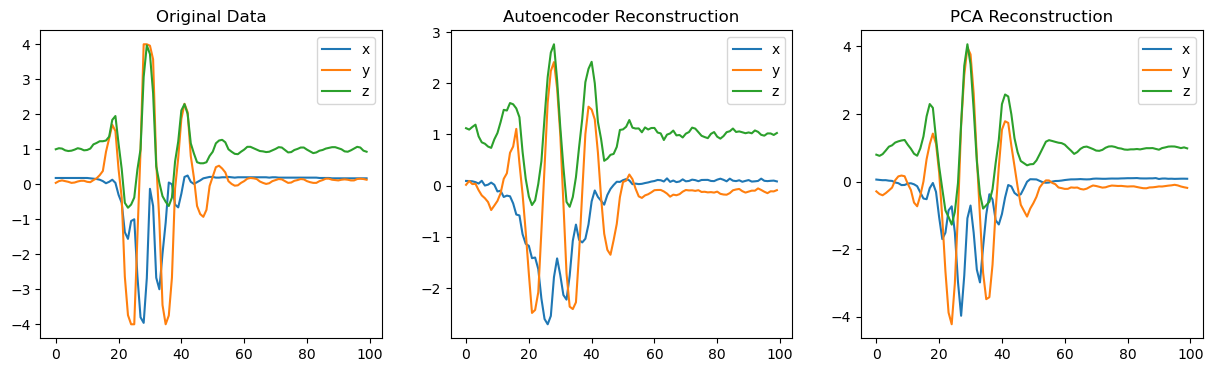

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Définir le nombre de composants de la PCA pour correspondre à la taille de l'espace latent (8 dans notre cas)
n_components = 8
pca = PCA(n_components=n_components)

# Réduire la dimension des données originales
x_flattened = x.reshape(x.shape[0], -1)  # Redimensionner en 2D pour la PCA
x_pca = pca.fit_transform(x_flattened)

# Reconstruire les données à partir de la PCA
x_reconstructed_pca = pca.inverse_transform(x_pca)
x_reconstructed_pca = x_reconstructed_pca.reshape(x.shape)  # Reshape en (50, 100, 3)

# Fonction pour visualiser les résultats de la reconstruction
def plot_comparison(original, reconstructed_autoencoder, reconstructed_pca, index=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Données originales
    axes[0].plot(original[index, :, 0], label="x")
    axes[0].plot(original[index, :, 1], label="y")
    axes[0].plot(original[index, :, 2], label="z")
    axes[0].set_title("Original Data")
    axes[0].legend()
    
    # Reconstruction par l'auto-encodeur
    axes[1].plot(reconstructed_autoencoder[index, :, 0], label="x")
    axes[1].plot(reconstructed_autoencoder[index, :, 1], label="y")
    axes[1].plot(reconstructed_autoencoder[index, :, 2], label="z")
    axes[1].set_title("Autoencoder Reconstruction")
    axes[1].legend()
    
    # Reconstruction par PCA
    axes[2].plot(reconstructed_pca[index, :, 0], label="x")
    axes[2].plot(reconstructed_pca[index, :, 1], label="y")
    axes[2].plot(reconstructed_pca[index, :, 2], label="z")
    axes[2].set_title("PCA Reconstruction")
    axes[2].legend()
    
    plt.show()

# Effectuer la reconstruction avec l'auto-encodeur
reconstructed_autoencoder = autoencoder.predict(x)

# Comparer les reconstructions
plot_comparison(x, reconstructed_autoencoder, x_reconstructed_pca)


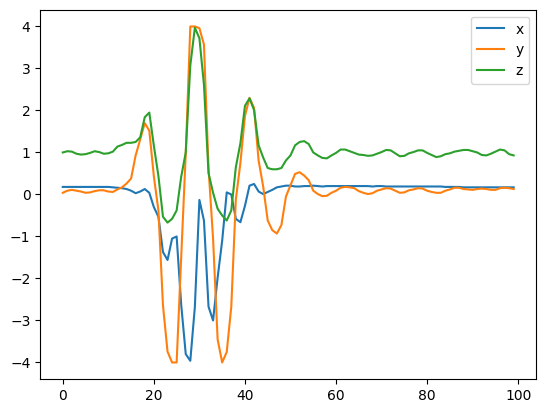

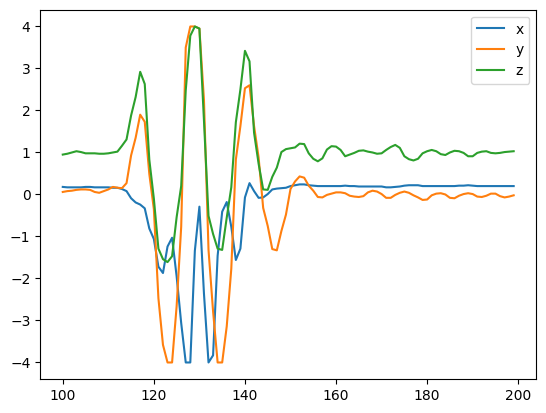

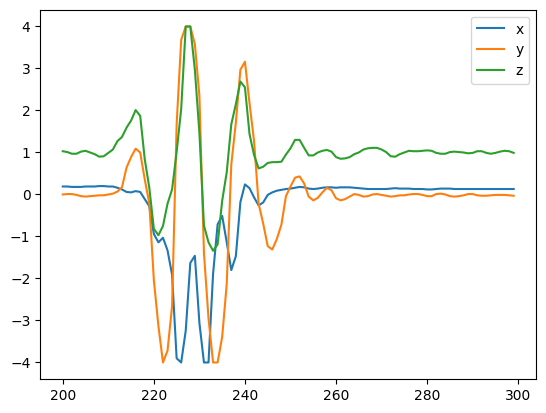

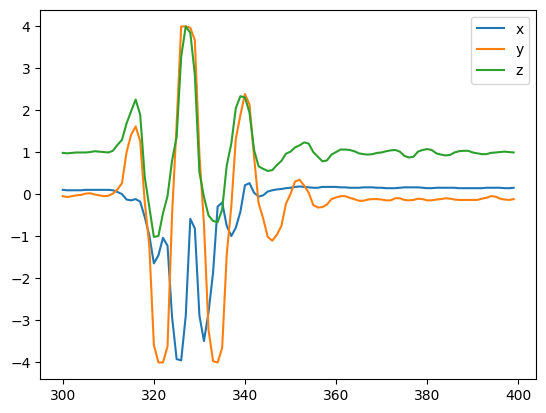

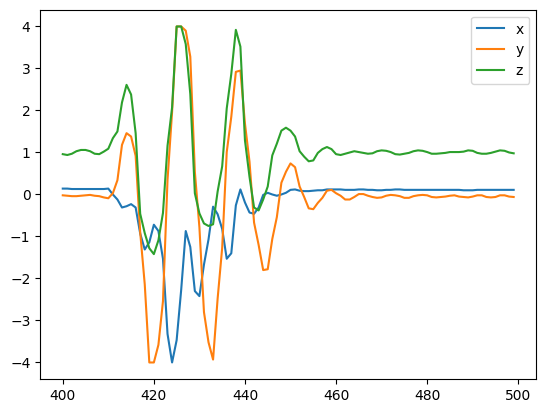

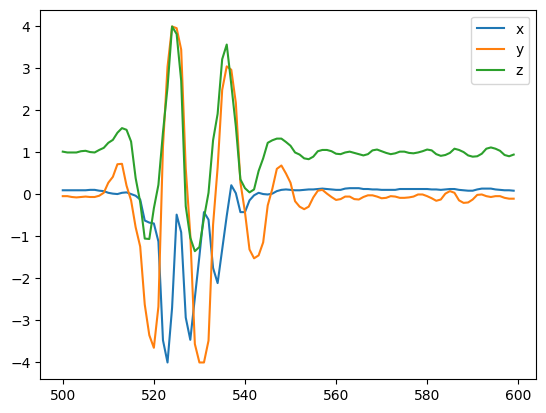

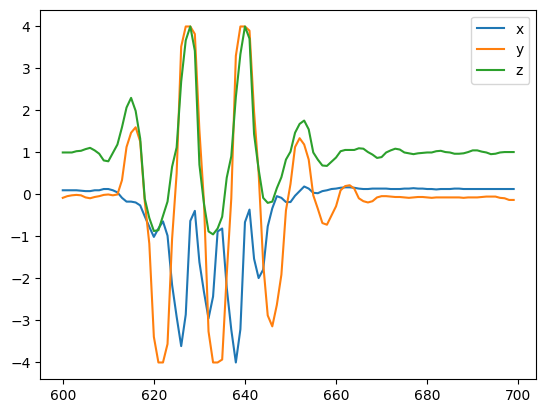

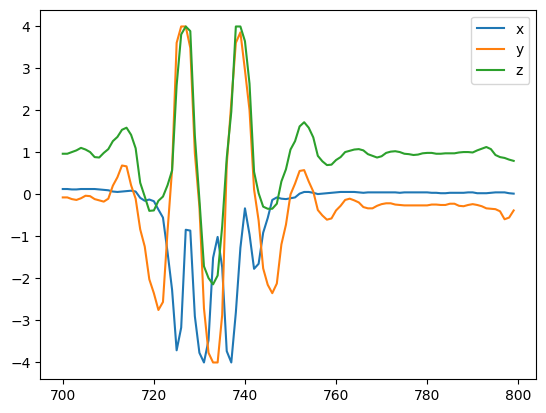

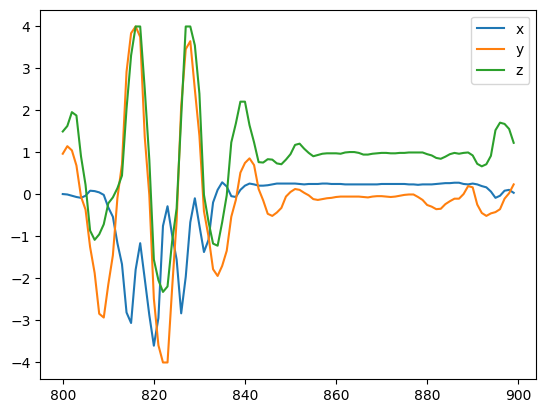

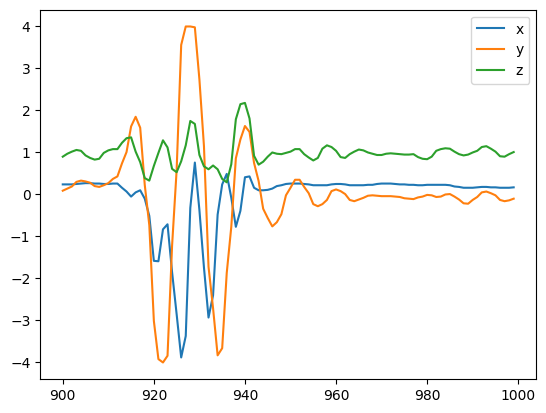

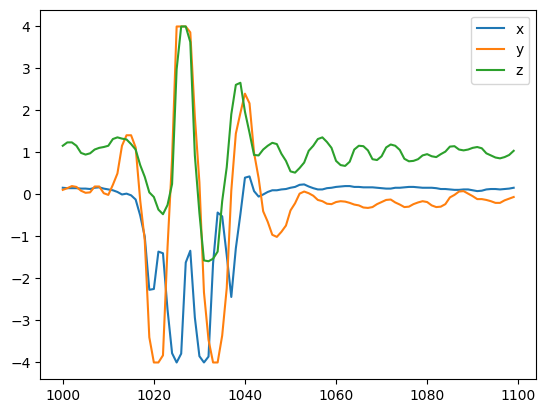

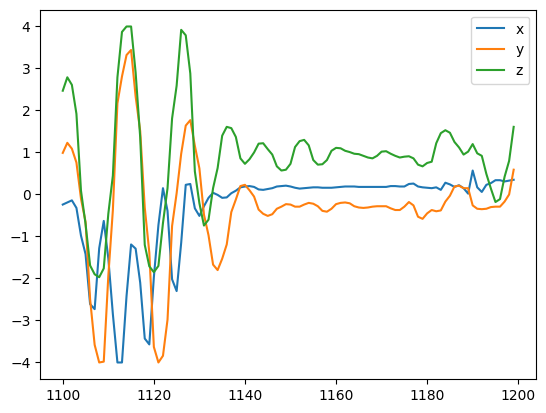

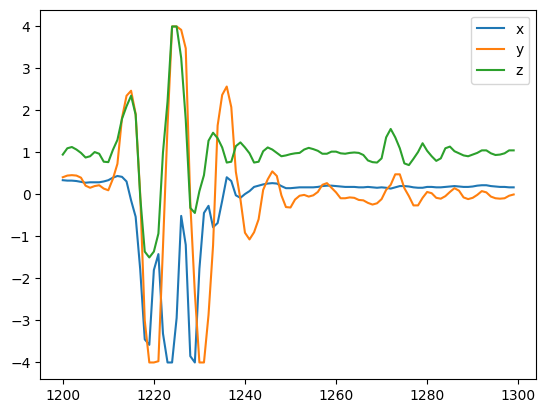

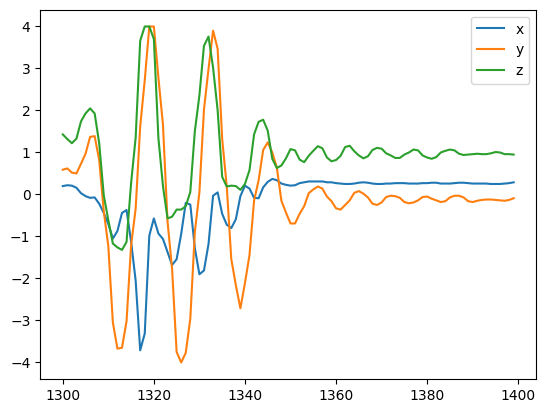

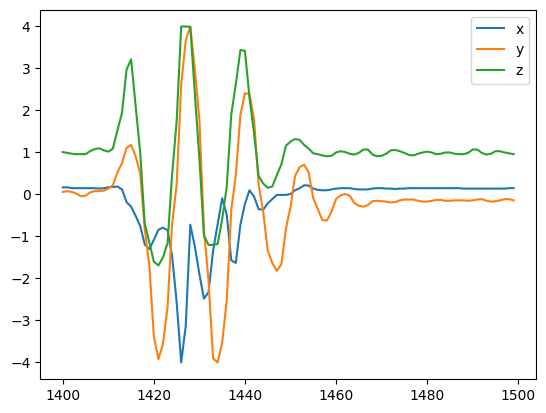

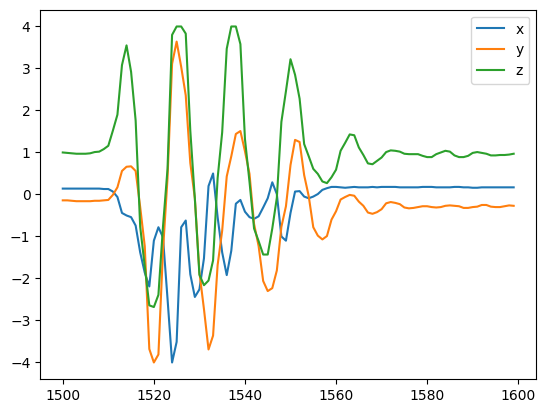

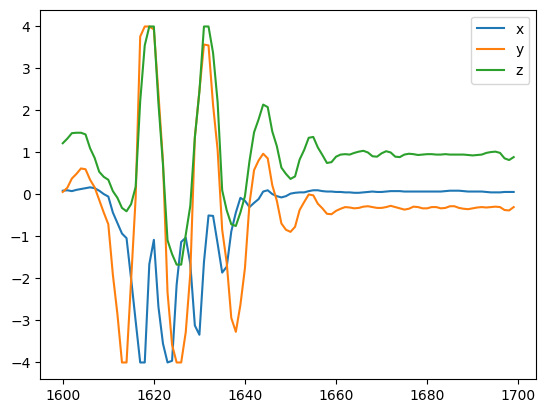

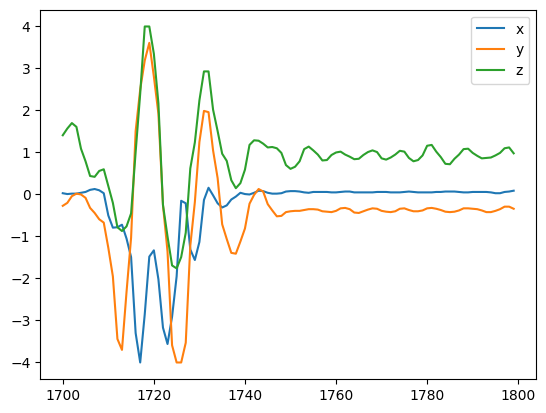

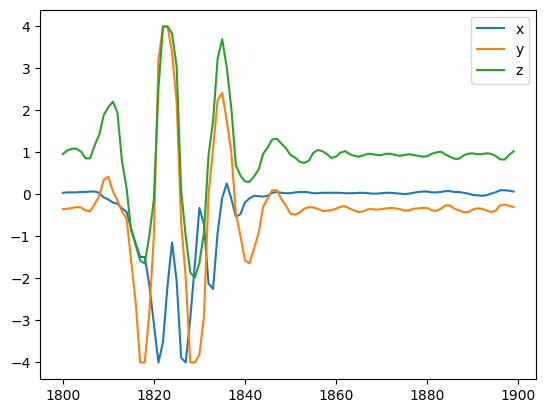

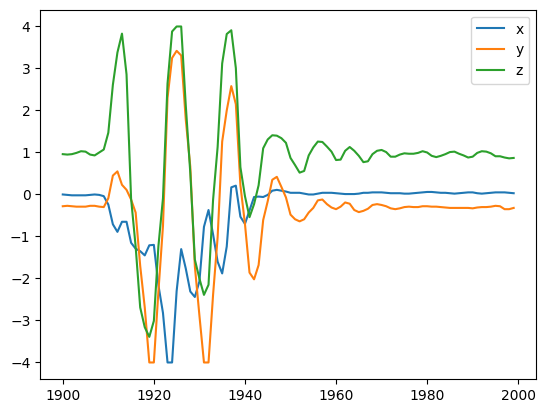

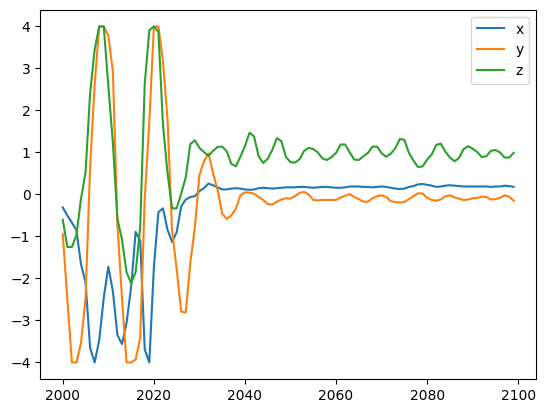

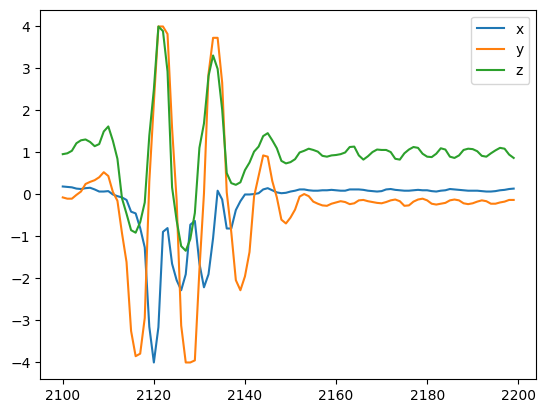

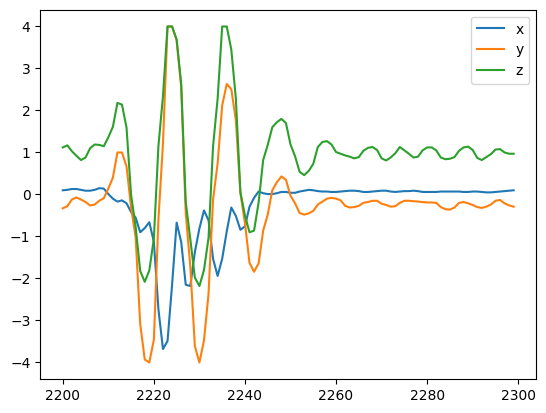

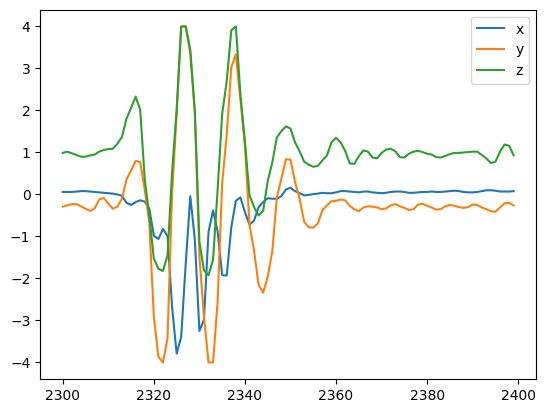

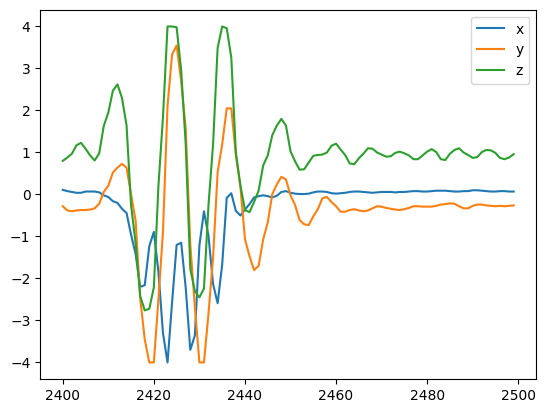

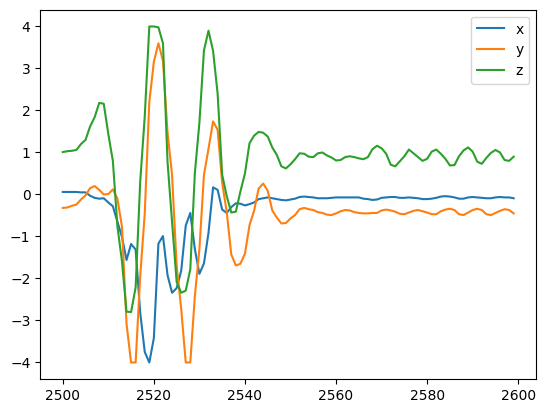

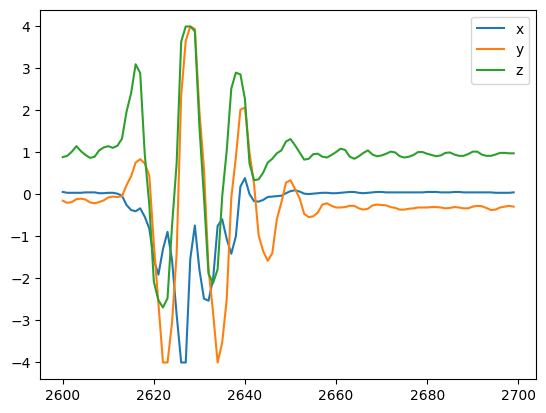

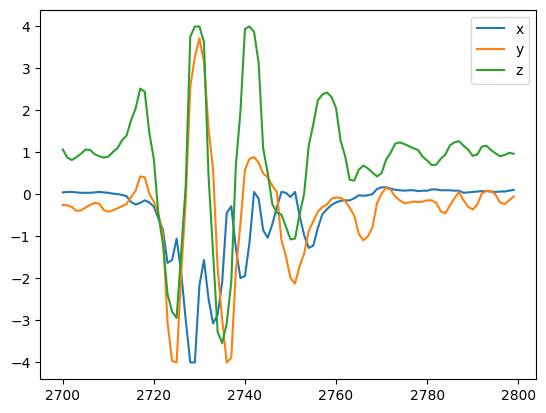

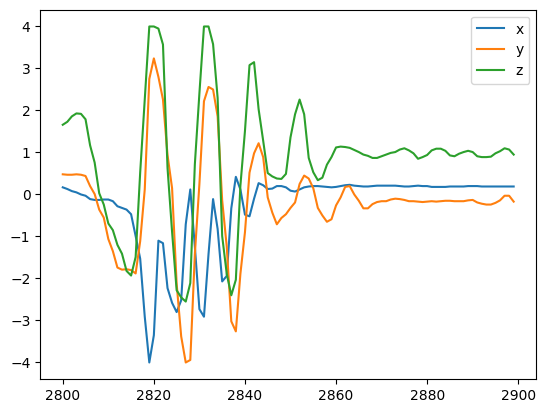

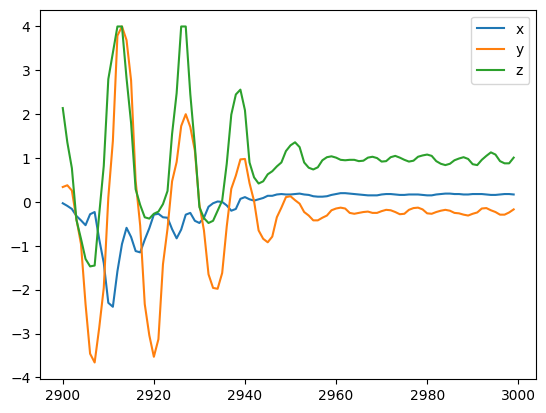

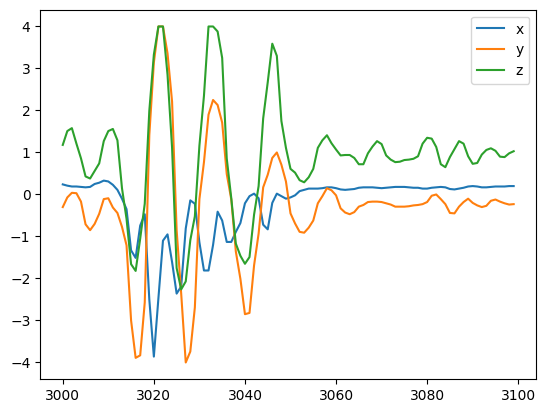

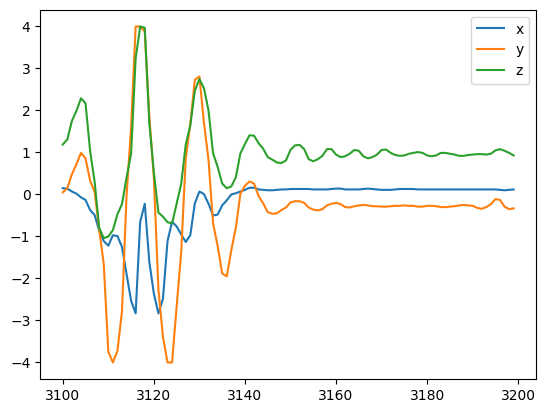

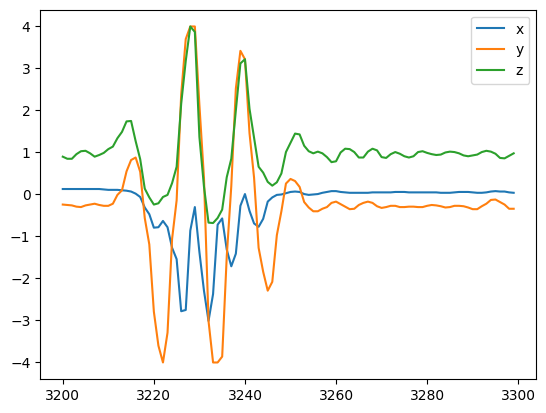

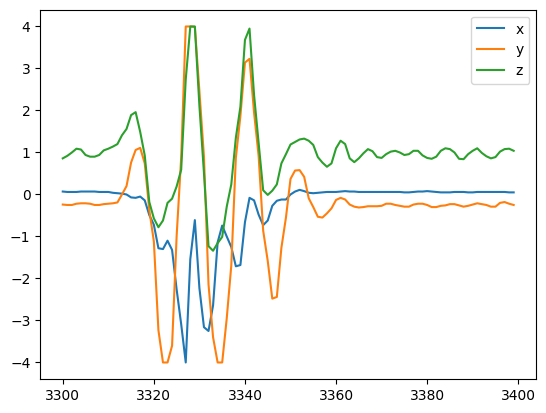

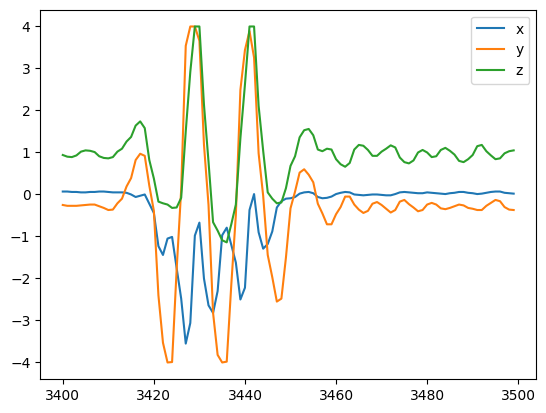

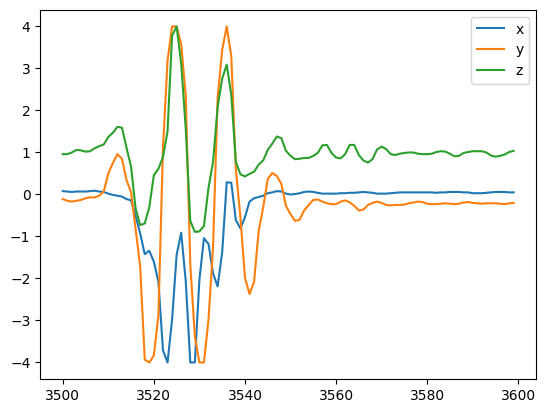

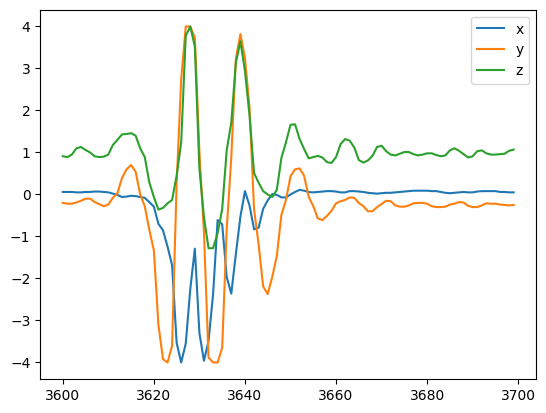

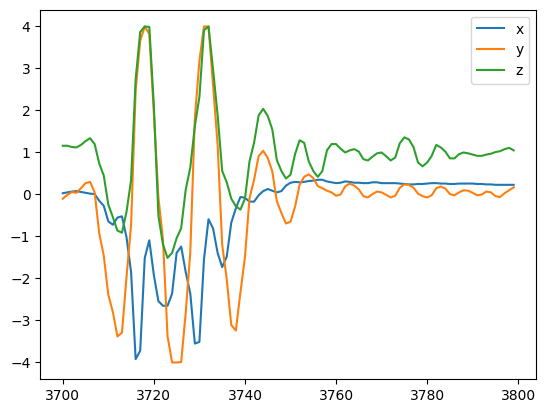

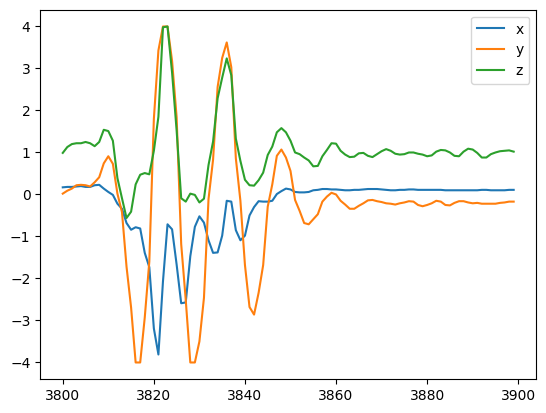

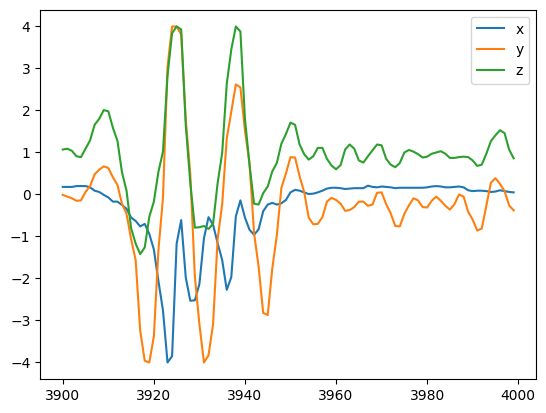

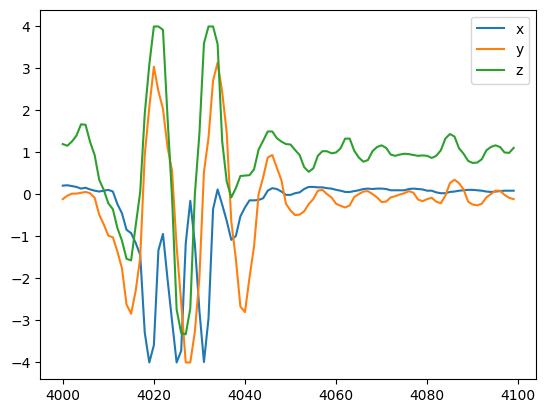

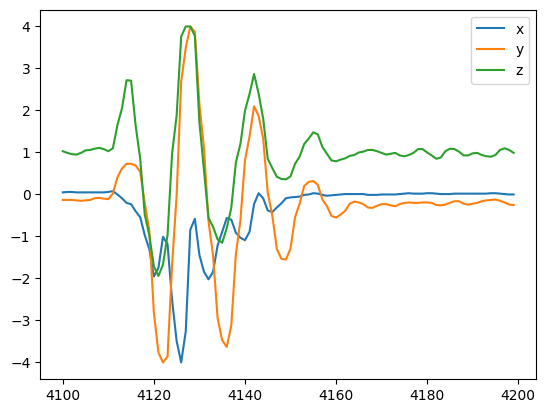

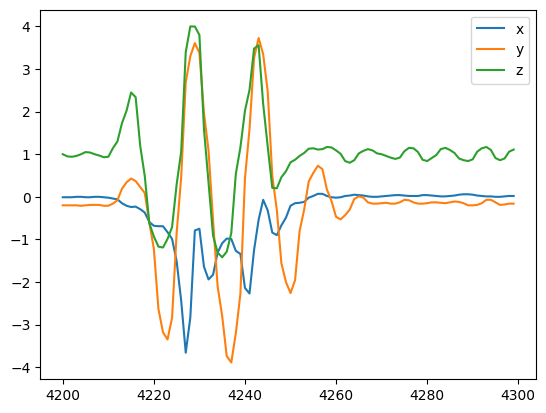

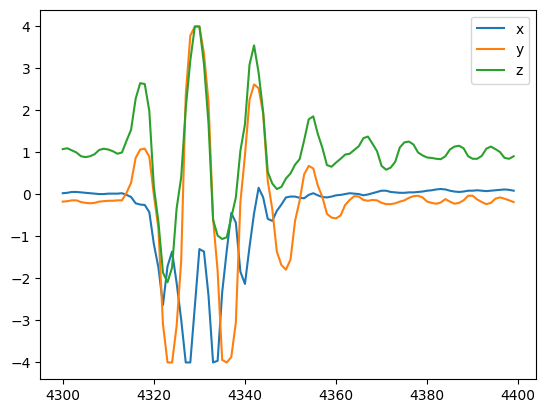

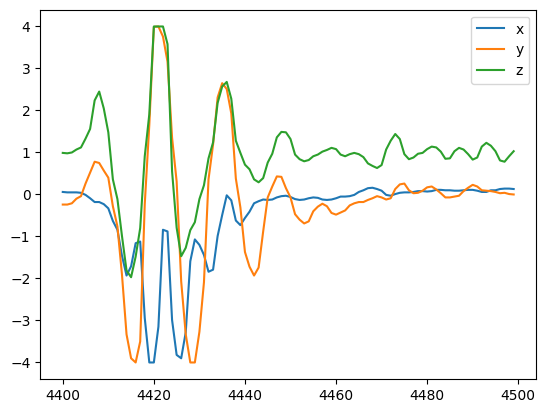

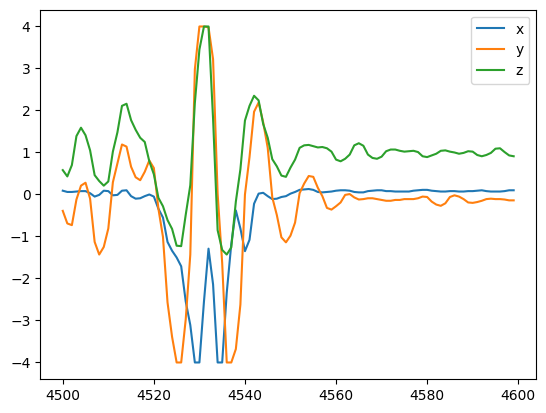

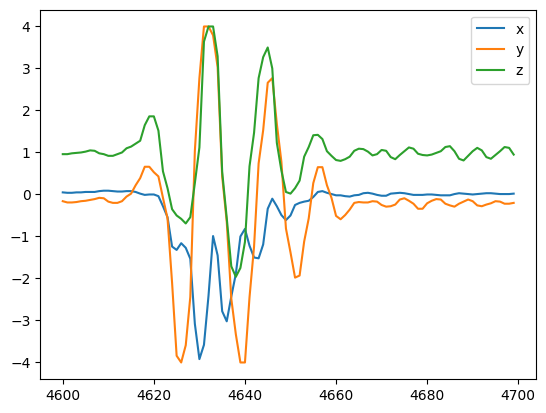

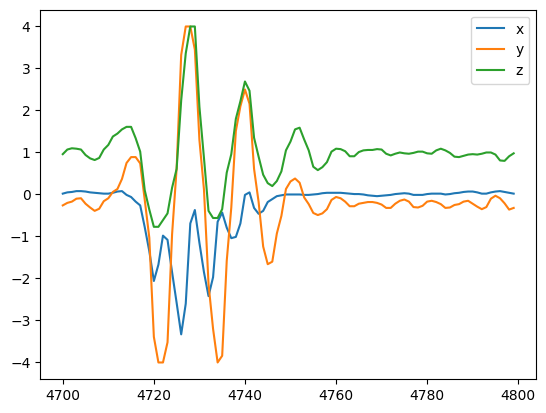

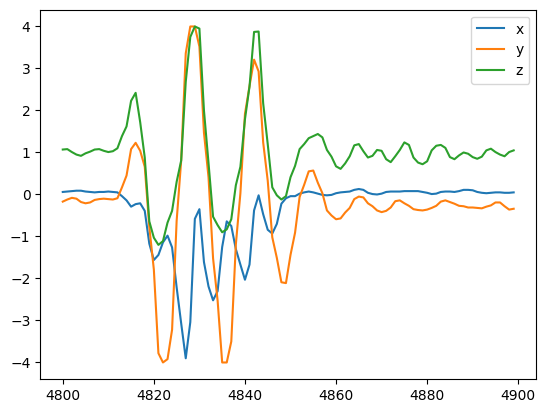

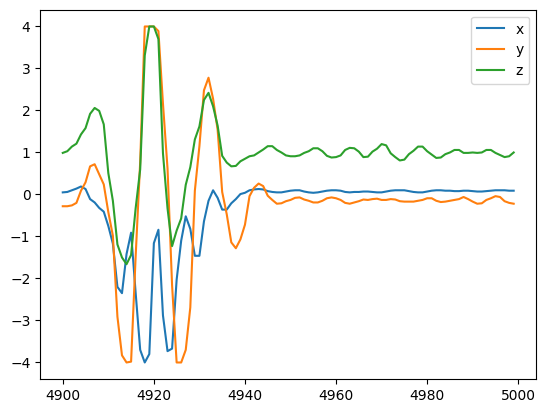

In [2]:
for i in range (0, 50):
    id_where_1 = df[df["id"] == i]
    plt.plot(id_where_1["x"], label="x")
    plt.plot(id_where_1["y"], label="y")
    plt.plot(id_where_1["z"], label="z")
    plt.legend()
    plt.show()

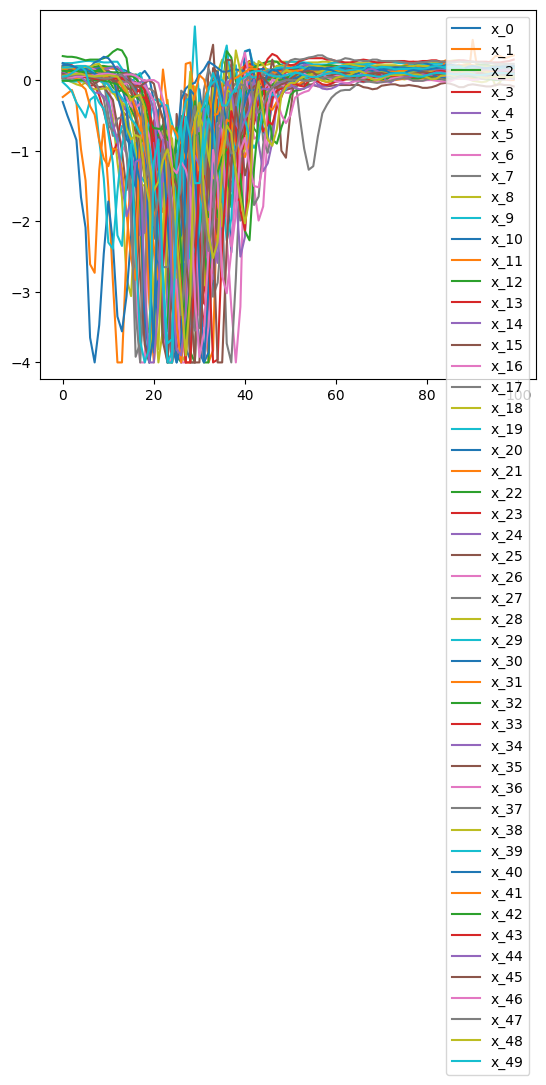

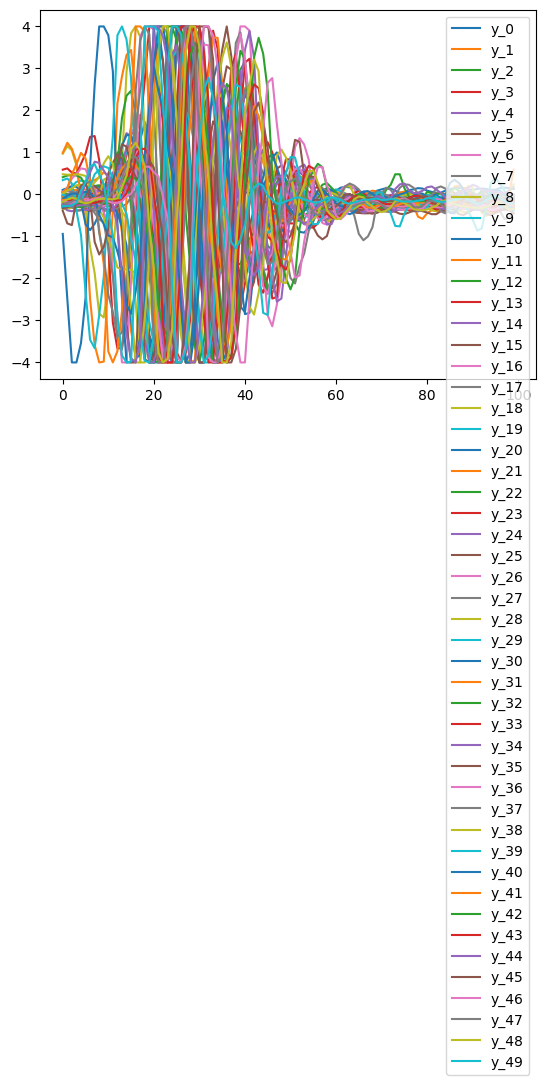

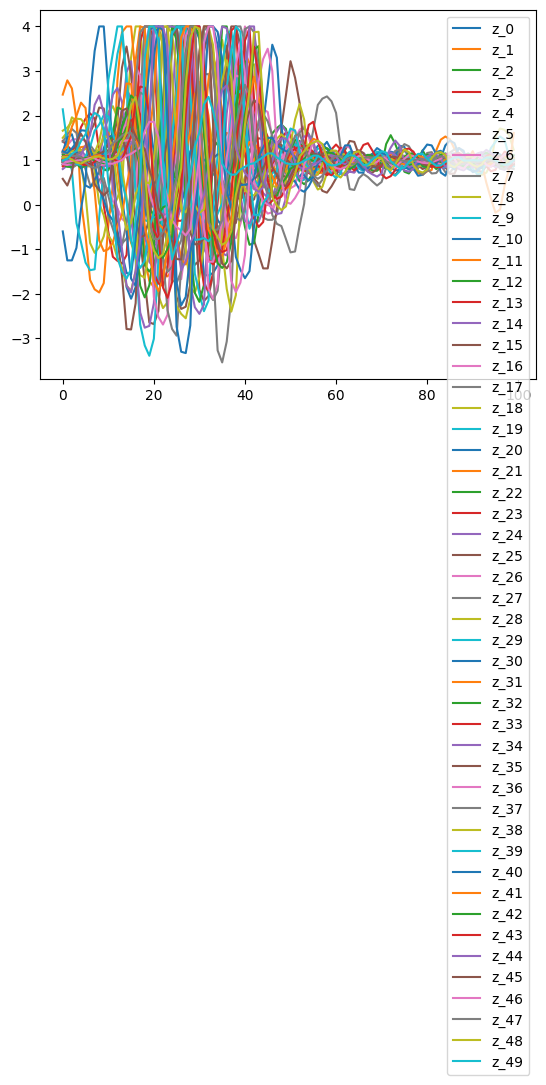

In [ ]:
for i in range (0, 50):
    x_values = df[df["id"] == i].reset_index()["x"]
    plt.plot(x_values)
plt.show()

for i in range (0, 50):
    y_values = df[df["id"] == i].reset_index()["y"]
    plt.plot(y_values)
plt.show()

for i in range (0, 50):
    z_values = df[df["id"] == i].reset_index()["z"]
    plt.plot(z_values)
plt.show()